# Model Predictions and Visualization

This notebook loads trained convCNP models and visualizes predictions on holdout time periods.

For each fold, we:
1. Load the trained model checkpoint
2. Identify the holdout time period for that fold
3. Select one deterministic day from the holdout period
4. Generate predictions for all spatial points
5. Plot side-by-side heatmaps: ERA5 Input | Ground Truth | Predictions | Bias

After processing all folds, the holdout predictions are combined (since holdout periods are non-overlapping) to produce a single unified evaluation with error maps, uncertainty calibration, CRPS, and skill scores.

In [1]:
%pip install -r requirements.txt

  Using cached plotly-6.5.2-py3-none-any.whl.metadata (8.5 kB)
Using cached plotly-6.5.2-py3-none-any.whl (9.9 MB)
  Attempting uninstall: plotly
    Found existing installation: plotly 6.3.1
    Not uninstalling plotly at /layers/paketo-buildpacks_poetry-install/poetry-venv/datascience-python-renku-dependencies-xS3fZVNL-py3.13/lib/python3.13/site-packages, outside environment /home/renku/work/.venv
    Can't uninstall 'plotly'. No files were found to uninstall.
Note: you may need to restart the kernel to use updated packages.


In [19]:
from collections import OrderedDict
from pathlib import Path
import os
import warnings

# Workaround #1 for NVML assertion failure on Renku MIG (Multi-Instance GPU) partitions.
# The CUDA caching allocator's "expandable segments" feature requires NVML calls that
# fail on MIG devices. Disabling this feature resolves the issue without significant
# performance impact.
if "RENKU_PROJECT_ID" in os.environ:
    os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:False,max_split_size_mb:512"

import matplotlib.pyplot as plt
import numpy as np
import properscoring as ps
import torch
import torch.nn as nn

from params import Params, load_params_json
from datasets import (
    Era5Metadata,
    load_metadata_json,
    load_era5_data,
    load_high_res_topography,
    prepare_meteoswiss_targets,
    calculate_dists_meteoswiss,
    get_meteoswiss_grid_shape,
    compute_seasonal_features,
    interpolate_era5_to_targets,
)
from metrics import skill_score
from convCNP.models.elev_models import TmaxBiasConvCNPElev, GammaBiasConvCNPElev
from convCNP.models.cnn import CNN, ResConvBlock
from convCNP.training.utils import get_sigma_tmax, get_value_tmax

In [3]:
if "RENKU_PROJECT_ID" in os.environ:
    device = torch.device('cuda')
elif torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')

print(f'Using device: {device}')

Using device: cuda


## Configuration

Specify the trained model directory to load.

In [4]:
# Path to trained model directory
MODEL_DIR = Path('./trained_models/base-2013+-30epochs-5folds-with-patience')

# Data paths (should match training)
# TODO: send these into the metadata at training, recover them here
ERA5_MAX_TEMP_GLOB = './datasets/ERA5_Land/max_temperature/*.nc'
ERA5_GEOPOTENTIAL_GLOB = './datasets/ERA5_Land/geopotential/*.nc'
METEO_SWISS_MAX_TEMP_GLOB = './datasets/MeteoSwiss/TmaxD_v2.0_swiss.lv95/*.nc'
HI_RES_TOPOGRAPHY_ZARR_PATH = './datasets/topo_subset.zarr'

## Load Training Configuration

In [5]:
# Load params and metadata from training
params = load_params_json(MODEL_DIR / 'params.json')
metadata = load_metadata_json(MODEL_DIR / 'metadata.json')

print(f"Loaded configuration for run: {params.TRIAL_NAME}")
print(f"  Variable: {params.VARIABLE}")
print(f"  Data year start: {params.DATA_YEAR_START}")
print(f"  N folds: {params.N_FOLDS}")
print(f"  Model: {params.N_CHANNELS} channels, {params.N_BLOCKS} blocks")

Loaded configuration for run: base-2013+-30epochs-5folds-with-patience
  Variable: tmax
  Data year start: 2014
  N folds: 5
  Model: 128 channels, 6 blocks


## Load Data

In [6]:
# Load ERA5 input data with geopotential
era5_data, _, era5_grid_elevation, era5_times = load_era5_data(
    ERA5_MAX_TEMP_GLOB,
    var_name='t2m_max',
    year_start=params.DATA_YEAR_START,
    geopotential_glob=ERA5_GEOPOTENTIAL_GLOB,
    device=device
)

print(f"ERA5 data shape: {era5_data.shape}")
print(f"Time coordinates: {len(era5_times)} dates from {era5_times[0]} to {era5_times[-1]}")

# Compute seasonal features from time coordinates if the model was trained with them
if params.SEASONAL_FEATURES_IN_MLP:
    seasonal_features = compute_seasonal_features(era5_times, device=device)
    print(f"Seasonal features shape: {seasonal_features.shape}  # (n_times, 2) for [cos_doy, sin_doy]")
else:
    seasonal_features = None
    print("Seasonal features disabled (model was trained without them)")

# Load high-resolution topography (DEM and TPI)
hi_res_elevation, hi_res_tpi = load_high_res_topography(HI_RES_TOPOGRAPHY_ZARR_PATH)

Loading ERA5 data from: ./datasets/ERA5_Land/max_temperature/*.nc
Dataset loaded with dimensions: FrozenMappingWarningOnValuesAccess({'time': 23376, 'latitude': 29, 'longitude': 61})
Original dataset time range: 1960-01-01T00:00:00.000000000 to 2023-12-31T00:00:00.000000000
Filtered dataset time range from 2014: 2014-01-01T00:00:00.000000000 to 2023-12-31T00:00:00.000000000
Filtered dataset dimensions: FrozenMappingWarningOnValuesAccess({'time': 3652, 'latitude': 29, 'longitude': 61})
Calculating stats for t2m_max (Kelvin)...
Final tensor_Z torch tensor with shape (time, channel, lat, lon): torch.Size([3652, 5, 29, 61]), dtype: torch.float32

Loading geopotential data from: ./datasets/ERA5_Land/geopotential/*.nc
Geopotential dataset dimensions: FrozenMappingWarningOnValuesAccess({'time': 1, 'latitude': 51, 'longitude': 81})
Geopotential lat range: [44.0000, 49.0000], shape: (51,)
Geopotential lon range: [4.0000, 12.0000], shape: (81,)
ERA5 data lat range: [45.4000, 48.2000], shape: (29

In [7]:
# Load MeteoSwiss targets with elevation and TPI
target_x, target_y, target_topo = prepare_meteoswiss_targets(
    METEO_SWISS_MAX_TEMP_GLOB,
    normalization_stats=metadata,
    data_var='TmaxD',
    grid_elevation=era5_grid_elevation,
    hi_res_elevation=hi_res_elevation,
    hi_res_tpi=hi_res_tpi,
    convert_to_kelvin=True,
    year_start=params.DATA_YEAR_START,
    device=device,
)

# Convert to tensors
target_y_tensor = torch.from_numpy(target_y.values.astype(np.float32)).to(device)
print(f"Target Y shape: {target_y_tensor.shape}")
print(f"Target topo shape: {target_topo.shape}")

# Get grid shape for reshaping predictions
grid_N, grid_E = get_meteoswiss_grid_shape(METEO_SWISS_MAX_TEMP_GLOB)
print(f"MeteoSwiss grid shape: ({grid_N}, {grid_E})")

--- Preparing MeteoSwiss Targets (x, y, e) ---
Flattening (240, 370) grid to (point)...
Creating Target Coordinate Tensor (x)...

=== COORDINATE VERIFICATION ===
MeteoSwiss lat (first 5 points): [45.720608 45.720795 45.720974 45.721157 45.721336]
MeteoSwiss lon (first 5 points): [5.8268523 5.839691  5.8525305 5.86537   5.878209 ]
MeteoSwiss lat range: [45.6886, 47.8820]
MeteoSwiss lon range: [5.7613, 10.6919]

ERA5 normalization bounds (should overlap with MeteoSwiss if both in degrees):
ERA5 lat range: [45.4000, 48.2000]
ERA5 lon range: [5.0000, 11.0000]
=== END COORDINATE VERIFICATION ===

Creating Ground Truth Tensor (y) for TmaxD...
  -> Converting Celsius to Kelvin (+273.15) before normalization
Creating Elevation Tensor (e) [3 features]...
  -> Converting target coordinates to Swiss LV95 for hi-res DEM lookup...
  -> Interpolating hi-res DEM at target points...
  -> Interpolating ERA5 grid elevation at target points...
  -> True elevation range: [181.7, 4675.4] m
  -> Grid elevat

In [8]:
# Calculate distances
dists = calculate_dists_meteoswiss(metadata, target_x, device=device)
print(f"Distances shape: {dists.shape}")

# Elevation tensor is already loaded as target_topo
elev = target_topo
print(f"Elevation tensor shape: {elev.shape}")

Distances shape: torch.Size([88800, 29, 61])
Elevation tensor shape: torch.Size([88800, 3])


In [9]:
# Compute reference predictions: ERA5 bilinearly interpolated to target locations.
# This is a deterministic baseline representing "what ERA5 says at each station".
era5_ref_preds = interpolate_era5_to_targets(era5_data, target_x, metadata)
era5_ref_denorm = metadata.denormalize(era5_ref_preds.cpu().numpy()) - 273.15
print(f"Reference predictions shape: {era5_ref_denorm.shape}  # (time, n_points)")

Reference predictions shape: (3652, 88800)  # (time, n_points)


## Helper Functions

In [10]:
# TODO move the model architecture code to a common file to reuse across training and prediction
def load_model_checkpoint(checkpoint_path: Path, params: Params, device: torch.device):
    """
    Load a trained model from checkpoint.
    """
    # Build model architecture
    decoder = CNN(
        n_channels=params.N_CHANNELS,
        ConvBlock=ResConvBlock,
        n_blocks=params.N_BLOCKS,
        Conv=nn.Conv2d,
        Normalization=nn.Identity,
        kernel_size=params.KERNEL_SIZE
    )
    
    if params.VARIABLE == 'tmax':
        model = TmaxBiasConvCNPElev(
            decoder=decoder,
            in_channels=params.IN_CHANNELS,
            ls=params.LENGTH_SCALE,
            use_seasonal=params.SEASONAL_FEATURES_IN_MLP
        )
    elif params.VARIABLE == 'precip':
        model = GammaBiasConvCNPElev(
            decoder=decoder,
            in_channels=params.IN_CHANNELS,
            ls=params.LENGTH_SCALE,
            use_seasonal=params.SEASONAL_FEATURES_IN_MLP
        )
    else:
        raise ValueError(f"Unknown variable: {params.VARIABLE}")
    
    model.to(device)
    
    # Load weights
    checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)
    
    # Handle potential 'module.' prefix from DataParallel
    state_dict = checkpoint['model_state_dict']
    if list(state_dict.keys())[0].startswith('module.'):
        state_dict = OrderedDict([(k[7:], v) for k, v in state_dict.items()])
    
    model.load_state_dict(state_dict)
    model.eval()
    
    return model, checkpoint.get('epoch', -1)


# TODO: move this to train_elev.py so we don't have duplicated logic
def get_fold_holdout_indices(fold: int, n_folds: int, n_samples: int) -> tuple[int, int]:
    """
    Get the start and end indices for a fold's holdout period.
    Mirrors the logic in train_elev.
    """
    fold_size = n_samples // n_folds
    start = fold * fold_size
    end = start + fold_size
    if fold == n_folds - 1:
        end = n_samples
    return start, end


# TODO: move this to train_elev.py so we don't have duplicated logic
def select_holdout_day(fold: int, holdout_start: int, holdout_end: int, seed: int = 42) -> int:
    """
    Deterministically select one day from the holdout period.
    Uses the middle day of the holdout period for consistency.
    """
    # Use middle of holdout period for determinism
    holdout_length = holdout_end - holdout_start
    day_offset = holdout_length // 2
    return holdout_start + day_offset


# TODO: consider having a predictions library to hold this and other support functions
def predict_single_day(
    model: nn.Module,
    context: torch.Tensor,
    day_idx: int,
    dists: torch.Tensor,
    elev: torch.Tensor,
    seasonal: torch.Tensor | None,
    device: torch.device
) -> tuple[torch.Tensor, torch.Tensor]:
    """
    Generate predictions for a single day.
    
    Args:
        model: The trained model
        context: ERA5 context data
        day_idx: Index of the day to predict
        dists: Distance tensor
        elev: Elevation tensor
        seasonal: Seasonal features tensor (n_times, 2) with [cos_doy, sin_doy], or None if disabled
        device: Torch device
    
    Returns:
        Tuple of (predictions, sigma) tensors
    """
    model.eval()
    
    with torch.no_grad():
        # Get context for this day (add batch dimension)
        day_context = context[day_idx:day_idx+1]  # (1, channels, lat, lon)
        
        # Get seasonal features for this day if available
        day_seasonal = seasonal[day_idx:day_idx+1] if seasonal is not None else None  # (1, 2) or None
        
        # Create mask
        batch_size, channels, x, y = day_context.shape
        mask = torch.ones(batch_size, channels, x, y).to(device)
        
        # Forward pass with seasonal features (or None)
        output = model(day_context, mask, dists, elev, seasonal=day_seasonal)
        
        # Extract mean prediction (for tmax, output[:, :, 0] is the mean)
        predictions = get_value_tmax(output)  # (1, n_points)
        
        sigma = get_sigma_tmax(output)  # (1, n_points)
    return predictions.squeeze(0), sigma.squeeze(0)

## Visualization Function

In [11]:
def plot_prediction_comparison(
    truth: np.ndarray,
    predictions: np.ndarray,
    era5_input: np.ndarray,
    grid_shape: tuple[int, int],
    era5_shape: tuple[int, int],
    metadata: Era5Metadata,
    title: str,
    denormalize: bool = True,
    temp_range: tuple[float, float] = (-10, 30),
    residual_range: tuple[float, float] = (-10, 10)
):
    """
    Plot side-by-side heatmaps: ERA5 Input | Ground Truth | Predictions | Residuals

    Args:
        truth: Ground truth values (n_points,)
        predictions: Model predictions (n_points,)
        era5_input: ERA5 temperature input (lat, lon) - normalized
        grid_shape: (N, E) shape for reshaping MeteoSwiss data
        era5_shape: (lat, lon) shape of ERA5 grid
        metadata: Era5Metadata for denormalization
        title: Plot title
        denormalize: If True, convert from normalized to Kelvin then Celsius
        temp_range: (min, max) temperature range in °C for truth/predictions
        residual_range: (min, max) range in °C for residuals
    """
    from scipy.ndimage import zoom

    # Reshape to 2D grid
    N, E = grid_shape
    truth_grid = truth.reshape(N, E)
    pred_grid = predictions.reshape(N, E)

    # Mask predictions to only show where ground truth is valid
    valid_mask = ~np.isnan(truth_grid)
    pred_grid = np.where(valid_mask, pred_grid, np.nan)

    # Upsample ERA5 to MeteoSwiss resolution and apply same mask
    era5_lat, era5_lon = era5_shape
    zoom_factors = (N / era5_lat, E / era5_lon)
    era5_upsampled = zoom(era5_input, zoom_factors, order=0)  # bilinear interpolation
    # ERA5 NetCDF files store latitude in decreasing order (north to south), so the first row
    # era5_data[day_idx, 0][0, :] is the northern edge. When we use origin='lower' with imshow,
    # row 0 is placed at the bottom, putting north at the bottom instead of the top. We could
    # go the other way, but then we would need to flip the mask too
    era5_upsampled = np.flipud(era5_upsampled)
    era5_upsampled = np.where(valid_mask, era5_upsampled, np.nan)

    # Denormalize if requested
    if denormalize:
        # Convert from normalized to Kelvin
        truth_grid = metadata.denormalize(truth_grid)
        pred_grid = metadata.denormalize(pred_grid)
        era5_upsampled = metadata.denormalize(era5_upsampled)
        # Convert Kelvin to Celsius
        truth_grid = truth_grid - 273.15
        pred_grid = pred_grid - 273.15
        era5_upsampled = era5_upsampled - 273.15
        unit = '°C'
    else:
        unit = 'normalized'

    # Calculate residuals
    residuals_grid = pred_grid - truth_grid

    # Create figure with 4 subplots
    fig, axes = plt.subplots(1, 4, figsize=(24, 6))

    # Use fixed colormap ranges
    vmin, vmax = temp_range
    res_min, res_max = residual_range

    # ERA5 Input
    im0 = axes[0].imshow(era5_upsampled, cmap='RdYlBu_r', vmin=vmin, vmax=vmax, origin='lower')
    axes[0].set_title(f'ERA5 Input ({unit})')
    axes[0].set_xlabel('E (grid index)')
    axes[0].set_ylabel('N (grid index)')
    plt.colorbar(im0, ax=axes[0], shrink=0.8)

    # Ground Truth
    im1 = axes[1].imshow(truth_grid, cmap='RdYlBu_r', vmin=vmin, vmax=vmax, origin='lower')
    axes[1].set_title(f'Ground Truth ({unit})')
    axes[1].set_xlabel('E (grid index)')
    axes[1].set_ylabel('N (grid index)')
    plt.colorbar(im1, ax=axes[1], shrink=0.8)

    # Predictions
    im2 = axes[2].imshow(pred_grid, cmap='RdYlBu_r', vmin=vmin, vmax=vmax, origin='lower')
    axes[2].set_title(f'Predictions ({unit})')
    axes[2].set_xlabel('E (grid index)')
    axes[2].set_ylabel('N (grid index)')
    plt.colorbar(im2, ax=axes[2], shrink=0.8)

    # Residuals (Bias)
    im3 = axes[3].imshow(residuals_grid, cmap='RdBu_r', vmin=res_min, vmax=res_max, origin='lower')
    axes[3].set_title(f'Bias (Pred - Truth, {unit})')
    axes[3].set_xlabel('E (grid index)')
    axes[3].set_ylabel('N (grid index)')
    plt.colorbar(im3, ax=axes[3], shrink=0.8)

    # Add statistics to residuals plot
    valid_residuals = residuals_grid[~np.isnan(residuals_grid)]
    mae = np.mean(np.abs(valid_residuals))
    rmse = np.sqrt(np.mean(valid_residuals**2))
    bias = np.mean(valid_residuals)
    stats_text = f'MAE: {mae:.2f}{unit}\nRMSE: {rmse:.2f}{unit}\nBias: {bias:.2f}{unit}'
    axes[3].text(0.02, 0.98, stats_text, transform=axes[3].transAxes,
                 verticalalignment='top', fontsize=10,
                 bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    fig.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()

    return fig


def plot_error_maps(
    mae_grid: np.ndarray,
    rmse_grid: np.ndarray,
    bias_grid: np.ndarray,
    title: str,
    error_range: tuple[float, float] = (0, 5),
    bias_range: tuple[float, float] = (-3, 3)
):
    """
    Plot per-pixel error magnitude maps: MAE | RMSE | Mean Bias
    
    Args:
        mae_grid: Per-pixel MAE values (N, E)
        rmse_grid: Per-pixel RMSE values (N, E)
        bias_grid: Per-pixel mean bias values (N, E)
        title: Plot title
        error_range: (min, max) range for MAE/RMSE colorbar
        bias_range: (min, max) range for bias colorbar
    """
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    err_min, err_max = error_range
    bias_min, bias_max = bias_range
    
    # MAE Map
    im0 = axes[0].imshow(mae_grid, cmap='YlOrRd', vmin=err_min, vmax=err_max, origin='lower')
    axes[0].set_title('Per-Pixel MAE (°C)')
    axes[0].set_xlabel('E (grid index)')
    axes[0].set_ylabel('N (grid index)')
    plt.colorbar(im0, ax=axes[0], shrink=0.8)
    
    # Add overall MAE statistic
    valid_mae = mae_grid[~np.isnan(mae_grid)]
    mean_mae = np.mean(valid_mae)
    axes[0].text(0.02, 0.98, f'Mean: {mean_mae:.2f}°C', transform=axes[0].transAxes,
                 verticalalignment='top', fontsize=10,
                 bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    # RMSE Map
    im1 = axes[1].imshow(rmse_grid, cmap='YlOrRd', vmin=err_min, vmax=err_max, origin='lower')
    axes[1].set_title('Per-Pixel RMSE (°C)')
    axes[1].set_xlabel('E (grid index)')
    axes[1].set_ylabel('N (grid index)')
    plt.colorbar(im1, ax=axes[1], shrink=0.8)
    
    # Add overall RMSE statistic
    valid_rmse = rmse_grid[~np.isnan(rmse_grid)]
    mean_rmse = np.mean(valid_rmse)
    axes[1].text(0.02, 0.98, f'Mean: {mean_rmse:.2f}°C', transform=axes[1].transAxes,
                 verticalalignment='top', fontsize=10,
                 bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    # Mean Bias Map
    im2 = axes[2].imshow(bias_grid, cmap='RdBu_r', vmin=bias_min, vmax=bias_max, origin='lower')
    axes[2].set_title('Per-Pixel Mean Bias (°C)')
    axes[2].set_xlabel('E (grid index)')
    axes[2].set_ylabel('N (grid index)')
    plt.colorbar(im2, ax=axes[2], shrink=0.8)
    
    # Add overall bias statistic
    valid_bias = bias_grid[~np.isnan(bias_grid)]
    mean_bias = np.mean(valid_bias)
    axes[2].text(0.02, 0.98, f'Mean: {mean_bias:.2f}°C', transform=axes[2].transAxes,
                 verticalalignment='top', fontsize=10,
                 bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    fig.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    
    return fig


def plot_uncertainty_vs_error(
    sigma_grid: np.ndarray,
    abs_error_grid: np.ndarray,
    title: str,
    sigma_range: tuple[float, float] = (0, 5),
    error_range: tuple[float, float] = (0, 10)
):
    """
    Plot uncertainty (sigma) vs absolute error to check if uncertainty correlates with errors.
    
    Ideally, high sigma values should appear in the same locations as high errors,
    indicating the model "knows" where it is uncertain.
    
    Args:
        sigma_grid: Predicted sigma values (N, E) in °C
        abs_error_grid: Absolute error |pred - truth| (N, E) in °C
        title: Plot title
        sigma_range: (min, max) range for sigma colorbar
        error_range: (min, max) range for absolute error colorbar
    """
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    sig_min, sig_max = sigma_range
    err_min, err_max = error_range
    
    # Uncertainty (Sigma) Map
    im0 = axes[0].imshow(sigma_grid, cmap='Purples', vmin=sig_min, vmax=sig_max, origin='lower')
    axes[0].set_title('Predicted Uncertainty (σ, °C)')
    axes[0].set_xlabel('E (grid index)')
    axes[0].set_ylabel('N (grid index)')
    plt.colorbar(im0, ax=axes[0], shrink=0.8)
    
    valid_sigma = sigma_grid[~np.isnan(sigma_grid)]
    mean_sigma = np.mean(valid_sigma)
    axes[0].text(0.02, 0.98, f'Mean σ: {mean_sigma:.2f}°C', transform=axes[0].transAxes,
                 verticalalignment='top', fontsize=10,
                 bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    # Absolute Error Map
    im1 = axes[1].imshow(abs_error_grid, cmap='YlOrRd', vmin=err_min, vmax=err_max, origin='lower')
    axes[1].set_title('Absolute Error (|Pred - Truth|, °C)')
    axes[1].set_xlabel('E (grid index)')
    axes[1].set_ylabel('N (grid index)')
    plt.colorbar(im1, ax=axes[1], shrink=0.8)
    
    valid_error = abs_error_grid[~np.isnan(abs_error_grid)]
    mean_error = np.mean(valid_error)
    axes[1].text(0.02, 0.98, f'Mean: {mean_error:.2f}°C', transform=axes[1].transAxes,
                 verticalalignment='top', fontsize=10,
                 bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    # Scatter plot: Sigma vs Absolute Error
    valid_mask = ~np.isnan(sigma_grid) & ~np.isnan(abs_error_grid)
    sigma_flat = sigma_grid[valid_mask]
    error_flat = abs_error_grid[valid_mask]
    
    # Subsample for scatter plot if too many points
    n_points = len(sigma_flat)
    if n_points > 5000:
        idx = np.random.choice(n_points, 5000, replace=False)
        sigma_sample = sigma_flat[idx]
        error_sample = error_flat[idx]
    else:
        sigma_sample = sigma_flat
        error_sample = error_flat
    
    axes[2].scatter(sigma_sample, error_sample, alpha=0.3, s=5, c='steelblue')
    axes[2].set_xlabel('Predicted σ (°C)')
    axes[2].set_ylabel('Absolute Error (°C)')
    axes[2].set_title('Uncertainty vs Error Correlation')
    
    # Add correlation coefficient
    correlation = np.corrcoef(sigma_flat, error_flat)[0, 1]
    axes[2].text(0.02, 0.98, f'Correlation: {correlation:.3f}', transform=axes[2].transAxes,
                 verticalalignment='top', fontsize=10,
                 bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    fig.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    
    return fig

In [12]:
def plot_crps_map(
    crps_grid: np.ndarray,
    title: str,
    crps_range: tuple[float, float] = (0, 3)
):
    """
    Plot per-pixel CRPS map.
    
    Args:
        crps_grid: Per-pixel mean CRPS values (N, E)
        title: Plot title
        crps_range: (min, max) range for CRPS colorbar
    """
    fig, ax = plt.subplots(1, 1, figsize=(8, 6))
    
    crps_min, crps_max = crps_range
    
    im = ax.imshow(crps_grid, cmap='YlOrRd', vmin=crps_min, vmax=crps_max, origin='lower')
    ax.set_title('Per-Pixel Mean CRPS (°C)')
    ax.set_xlabel('E (grid index)')
    ax.set_ylabel('N (grid index)')
    plt.colorbar(im, ax=ax, shrink=0.8)
    
    # Add overall CRPS statistic
    valid_crps = crps_grid[~np.isnan(crps_grid)]
    mean_crps = np.mean(valid_crps)
    ax.text(0.02, 0.98, f'Overall CRPS: {mean_crps:.3f}°C', transform=ax.transAxes,
            verticalalignment='top', fontsize=10,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    fig.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    
    return fig, mean_crps

In [13]:
def plot_skill_map(
    skill_grid: np.ndarray,
    global_skill: float,
    title: str,
    skill_range: tuple[float, float] = (-1, 1)
):
    """
    Plot per-pixel skill score map.

    Skill score = 1 - (CRPS_model / CRPS_reference).
    Positive = model beats ERA5 interpolation; negative = model is worse.

    Args:
        skill_grid: Per-pixel skill scores (N, E)
        global_skill: Global (spatially-averaged) skill score
        title: Plot title
        skill_range: (min, max) range for colorbar
    """
    fig, ax = plt.subplots(1, 1, figsize=(8, 6))

    skill_min, skill_max = skill_range

    im = ax.imshow(skill_grid, cmap='RdYlGn', vmin=skill_min, vmax=skill_max, origin='lower')
    ax.set_title('Per-Pixel Skill Score')
    ax.set_xlabel('E (grid index)')
    ax.set_ylabel('N (grid index)')
    plt.colorbar(im, ax=ax, shrink=0.8)

    # Add statistics
    valid_skill = skill_grid[~np.isnan(skill_grid)]
    median_skill = np.median(valid_skill)
    stats_text = f'Global skill: {global_skill:.3f}\nMedian pixel skill: {median_skill:.3f}'
    ax.text(0.02, 0.98, stats_text, transform=ax.transAxes,
            verticalalignment='top', fontsize=10,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    fig.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()

    return fig

In [14]:
def plot_perpixel_uncertainty_vs_error(
    mean_sigma_grid: np.ndarray,
    mae_grid: np.ndarray,
    title: str,
    sigma_range: tuple[float, float] = (0, 5),
    error_range: tuple[float, float] = (0, 5)
):
    """
    Plot per-pixel mean uncertainty (sigma) vs per-pixel MAE across all holdout days.
    
    This shows whether locations with high predicted uncertainty also tend to have
    high errors across the entire holdout period, indicating good spatial calibration.
    
    Args:
        mean_sigma_grid: Per-pixel mean predicted sigma (N, E) in °C
        mae_grid: Per-pixel MAE (N, E) in °C
        title: Plot title
        sigma_range: (min, max) range for sigma colorbar
        error_range: (min, max) range for MAE colorbar
    """
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    sig_min, sig_max = sigma_range
    err_min, err_max = error_range
    
    # Mean Uncertainty (Sigma) Map
    im0 = axes[0].imshow(mean_sigma_grid, cmap='Purples', vmin=sig_min, vmax=sig_max, origin='lower')
    axes[0].set_title('Per-Pixel Mean Uncertainty (σ, °C)')
    axes[0].set_xlabel('E (grid index)')
    axes[0].set_ylabel('N (grid index)')
    plt.colorbar(im0, ax=axes[0], shrink=0.8)
    
    valid_sigma = mean_sigma_grid[~np.isnan(mean_sigma_grid)]
    overall_mean_sigma = np.mean(valid_sigma)
    axes[0].text(0.02, 0.98, f'Mean σ: {overall_mean_sigma:.2f}°C', transform=axes[0].transAxes,
                 verticalalignment='top', fontsize=10,
                 bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    # MAE Map
    im1 = axes[1].imshow(mae_grid, cmap='YlOrRd', vmin=err_min, vmax=err_max, origin='lower')
    axes[1].set_title('Per-Pixel MAE (°C)')
    axes[1].set_xlabel('E (grid index)')
    axes[1].set_ylabel('N (grid index)')
    plt.colorbar(im1, ax=axes[1], shrink=0.8)
    
    valid_mae = mae_grid[~np.isnan(mae_grid)]
    overall_mae = np.mean(valid_mae)
    axes[1].text(0.02, 0.98, f'Mean: {overall_mae:.2f}°C', transform=axes[1].transAxes,
                 verticalalignment='top', fontsize=10,
                 bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    # Scatter plot: Mean Sigma vs MAE (per pixel)
    valid_mask = ~np.isnan(mean_sigma_grid) & ~np.isnan(mae_grid)
    sigma_flat = mean_sigma_grid[valid_mask]
    mae_flat = mae_grid[valid_mask]
    
    # Subsample for scatter plot if too many points
    n_points = len(sigma_flat)
    if n_points > 5000:
        idx = np.random.choice(n_points, 5000, replace=False)
        sigma_sample = sigma_flat[idx]
        mae_sample = mae_flat[idx]
    else:
        sigma_sample = sigma_flat
        mae_sample = mae_flat
    
    axes[2].scatter(sigma_sample, mae_sample, alpha=0.3, s=5, c='steelblue')
    axes[2].set_xlabel('Per-Pixel Mean σ (°C)')
    axes[2].set_ylabel('Per-Pixel MAE (°C)')
    axes[2].set_title('Uncertainty vs Error Correlation (per pixel)')
    
    # Add correlation coefficient
    correlation = np.corrcoef(sigma_flat, mae_flat)[0, 1]
    axes[2].text(0.02, 0.98, f'Correlation: {correlation:.3f}', transform=axes[2].transAxes,
                 verticalalignment='top', fontsize=10,
                 bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    fig.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    
    return fig, correlation

In [21]:
def plot_perpixel_correlation(
    x_grid: np.ndarray,
    y_grid: np.ndarray,
    x_label: str,
    y_label: str,
    title: str,
    x_range: tuple[float, float] | None = None,
    y_range: tuple[float, float] | None = None,
    x_cmap: str = 'viridis',
    y_cmap: str = 'YlOrRd'
):
    """
    Generic function to plot per-pixel correlation between two variables.
    
    Args:
        x_grid: First variable grid (N, E)
        y_grid: Second variable grid (N, E)
        x_label: Label for x variable
        y_label: Label for y variable
        title: Plot title
        x_range: (min, max) range for x colorbar
        y_range: (min, max) range for y colorbar
        x_cmap: Colormap for x variable
        y_cmap: Colormap for y variable
    """
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    # Auto-compute ranges if not provided
    if x_range is None:
        x_range = (np.nanmin(x_grid), np.nanmax(x_grid))
    if y_range is None:
        y_range = (np.nanmin(y_grid), np.nanmax(y_grid))
    
    x_min, x_max = x_range
    y_min, y_max = y_range
    
    # X variable Map
    im0 = axes[0].imshow(x_grid, cmap=x_cmap, vmin=x_min, vmax=x_max, origin='lower')
    axes[0].set_title(x_label)
    axes[0].set_xlabel('E (grid index)')
    axes[0].set_ylabel('N (grid index)')
    plt.colorbar(im0, ax=axes[0], shrink=0.8)
    
    valid_x = x_grid[~np.isnan(x_grid)]
    mean_x = np.mean(valid_x)
    axes[0].text(0.02, 0.98, f'Mean: {mean_x:.2f}', transform=axes[0].transAxes,
                 verticalalignment='top', fontsize=10,
                 bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    # Y variable Map
    im1 = axes[1].imshow(y_grid, cmap=y_cmap, vmin=y_min, vmax=y_max, origin='lower')
    axes[1].set_title(y_label)
    axes[1].set_xlabel('E (grid index)')
    axes[1].set_ylabel('N (grid index)')
    plt.colorbar(im1, ax=axes[1], shrink=0.8)
    
    valid_y = y_grid[~np.isnan(y_grid)]
    mean_y = np.mean(valid_y)
    axes[1].text(0.02, 0.98, f'Mean: {mean_y:.2f}', transform=axes[1].transAxes,
                 verticalalignment='top', fontsize=10,
                 bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    # Scatter plot
    valid_mask = ~np.isnan(x_grid) & ~np.isnan(y_grid)
    x_flat = x_grid[valid_mask]
    y_flat = y_grid[valid_mask]
    
    # Subsample for scatter plot if too many points
    n_points = len(x_flat)
    if n_points > 5000:
        idx = np.random.choice(n_points, 5000, replace=False)
        x_sample = x_flat[idx]
        y_sample = y_flat[idx]
    else:
        x_sample = x_flat
        y_sample = y_flat
    
    axes[2].scatter(x_sample, y_sample, alpha=0.3, s=5, c='steelblue')
    axes[2].set_xlabel(x_label)
    axes[2].set_ylabel(y_label)
    axes[2].set_title(f'{x_label} vs {y_label}')
    
    # Add correlation coefficient
    correlation = np.corrcoef(x_flat, y_flat)[0, 1]
    axes[2].text(0.02, 0.98, f'Correlation: {correlation:.3f}', transform=axes[2].transAxes,
                 verticalalignment='top', fontsize=10,
                 bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    fig.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    
    return fig, correlation


def plot_temporal_error_analysis(
    all_errors: np.ndarray,
    holdout_dates: np.ndarray,
    title: str
):
    """
    Plot day of year vs mean absolute error scatter with correlation.
    
    Args:
        all_errors: Array of shape (holdout_days, n_points) with errors for each day/pixel
        holdout_dates: Array of datetime64 values for each holdout day
        title: Plot title
    
    Returns:
        fig: matplotlib figure
        correlation: Correlation between day of year and mean absolute error
    """
    import pandas as pd
    
    fig, ax = plt.subplots(1, 1, figsize=(8, 5))
    
    # Calculate mean absolute error per day (across all pixels)
    mae_per_day = np.nanmean(np.abs(all_errors), axis=1)
    
    # Convert datetime64 to day of year (1-365/366)
    dates_series = pd.to_datetime(holdout_dates)
    days_of_year = dates_series.dayofyear.values
    
    # Scatter plot with correlation
    ax.scatter(days_of_year, mae_per_day, alpha=0.6, s=30, c='steelblue')
    ax.set_xlabel('Day of Year')
    ax.set_ylabel('Mean Absolute Error (°C)')
    ax.set_title('Day of Year vs MAE Correlation')
    ax.set_xlim(1, 366)
    
    # Add correlation coefficient
    correlation = np.corrcoef(days_of_year, mae_per_day)[0, 1]
    ax.text(0.02, 0.98, f'Correlation: {correlation:.3f}', transform=ax.transAxes,
            verticalalignment='top', fontsize=10,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    fig.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    
    return fig, correlation

## Generate Predictions for Each Fold

For each fold, we load the trained model, plot a single representative holdout day, and accumulate predictions over the full holdout period for combined analysis.

Total time samples: 3652
Number of folds: 5
ERA5 grid shape: (29, 61)
MeteoSwiss grid shape: (240, 370)

Fold 1/5
  Loaded model from epoch 26
  Holdout period: days 0 to 729 (730 days)
  Holdout date range: 2014-01-01T00:00:00.000000000 to 2015-12-31T00:00:00.000000000
  Selected day index for single-day plot: 365


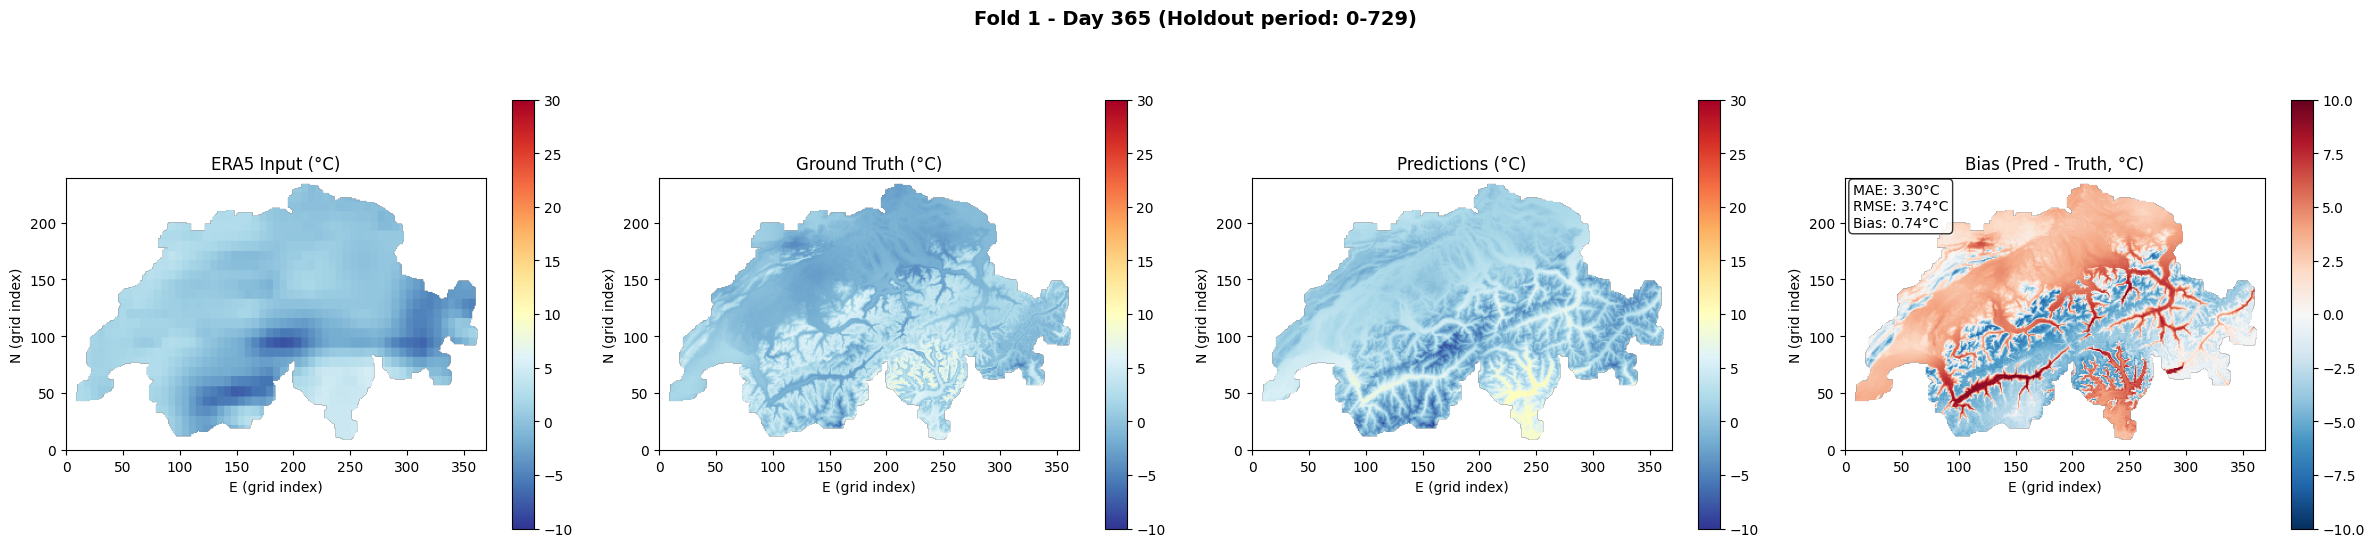

  Computing predictions for all 730 holdout days...
  Fold 1 done: accumulated 730 days

Fold 2/5
  Loaded model from epoch 29
  Holdout period: days 730 to 1459 (730 days)
  Holdout date range: 2016-01-01T00:00:00.000000000 to 2017-12-30T00:00:00.000000000
  Selected day index for single-day plot: 1095


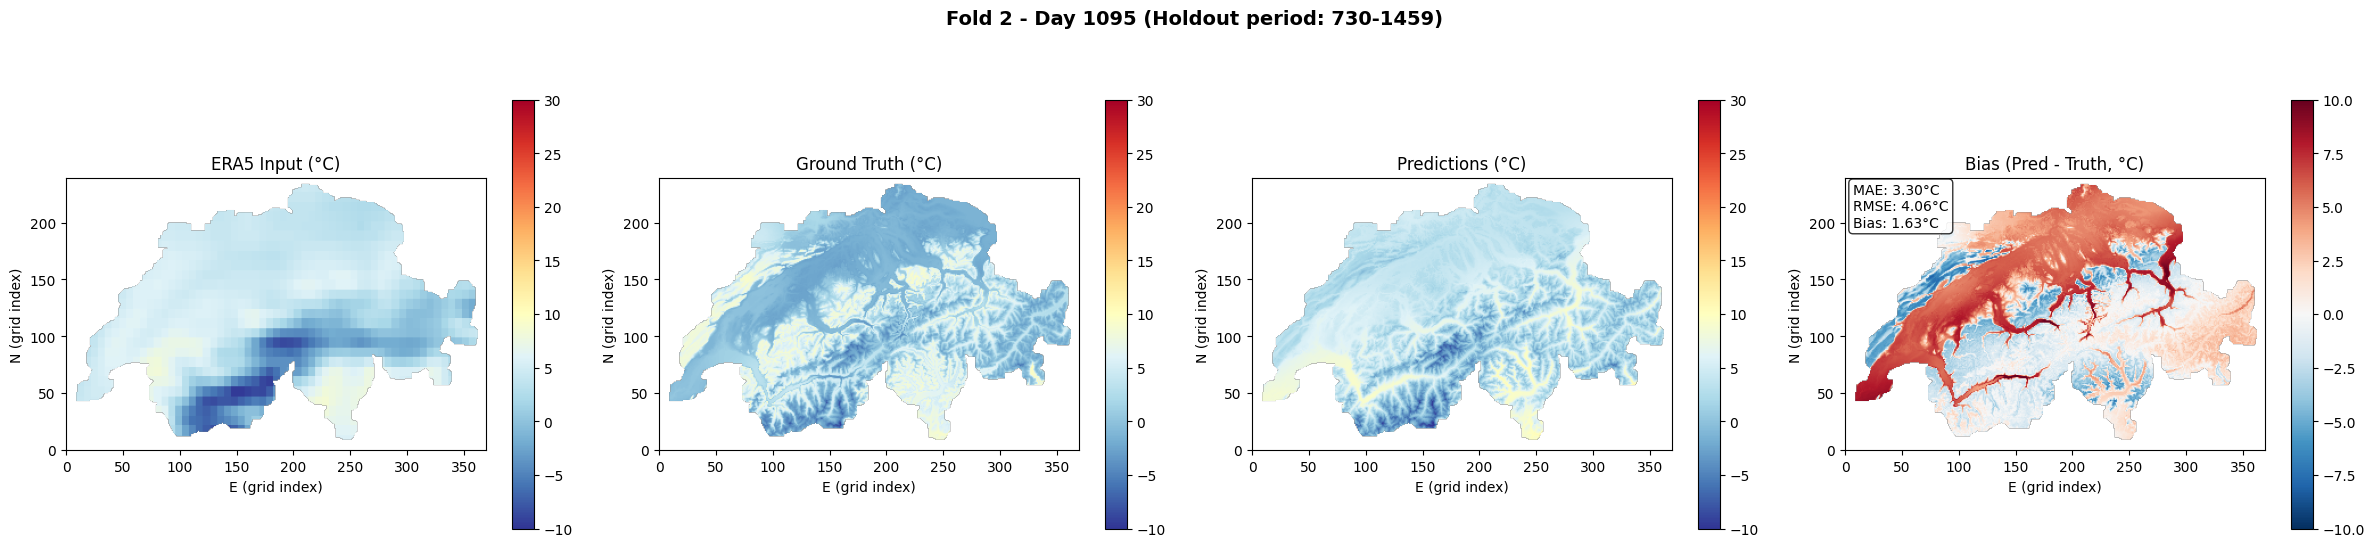

  Computing predictions for all 730 holdout days...
  Fold 2 done: accumulated 730 days

Fold 3/5
  Loaded model from epoch 28
  Holdout period: days 1460 to 2189 (730 days)
  Holdout date range: 2017-12-31T00:00:00.000000000 to 2019-12-30T00:00:00.000000000
  Selected day index for single-day plot: 1825


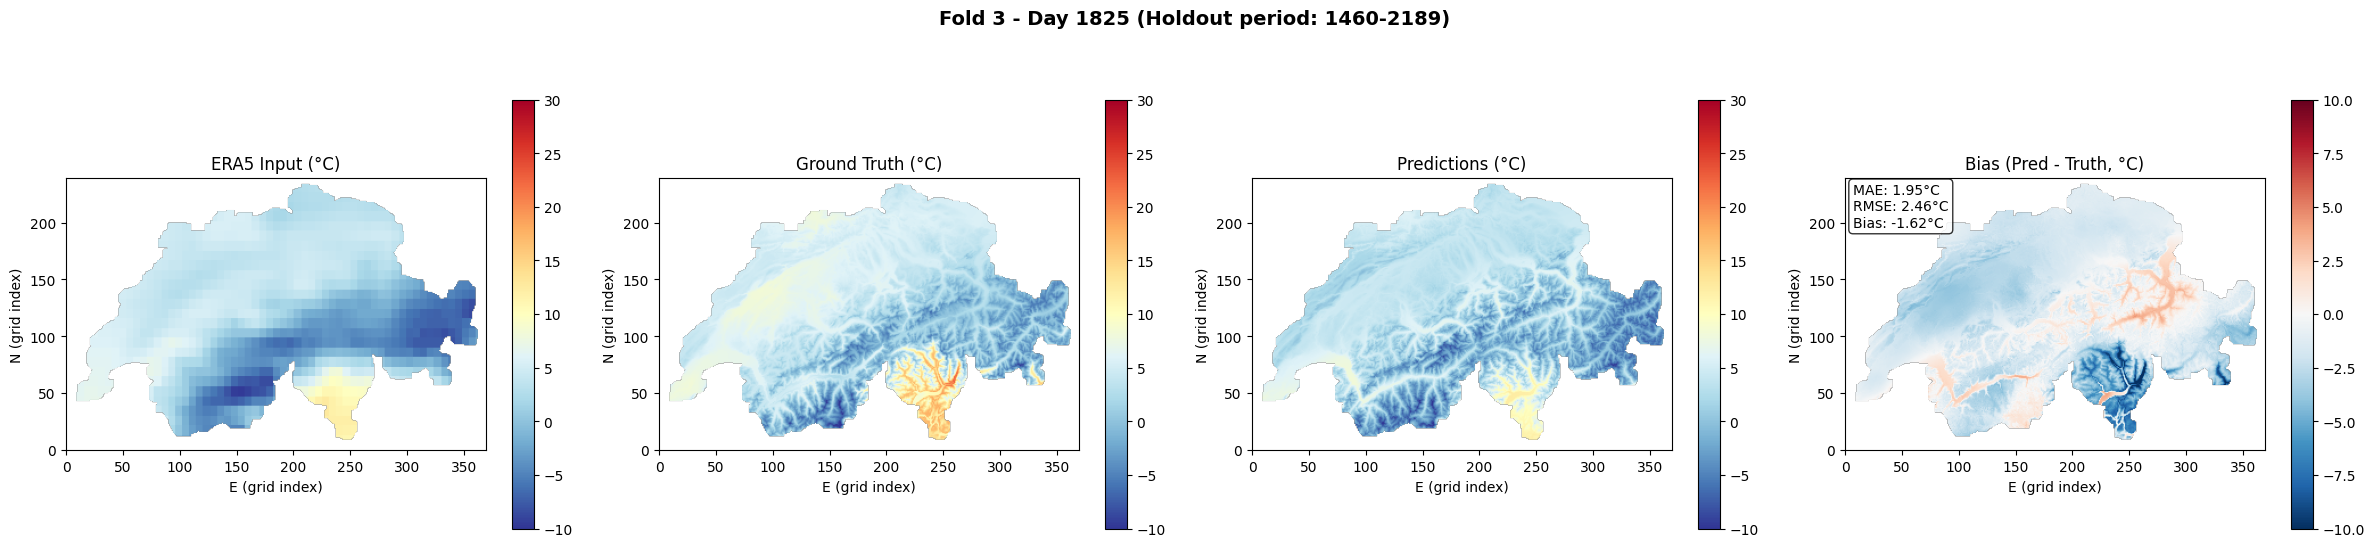

  Computing predictions for all 730 holdout days...
  Fold 3 done: accumulated 730 days

Fold 4/5
  Loaded model from epoch 27
  Holdout period: days 2190 to 2919 (730 days)
  Holdout date range: 2019-12-31T00:00:00.000000000 to 2021-12-29T00:00:00.000000000
  Selected day index for single-day plot: 2555


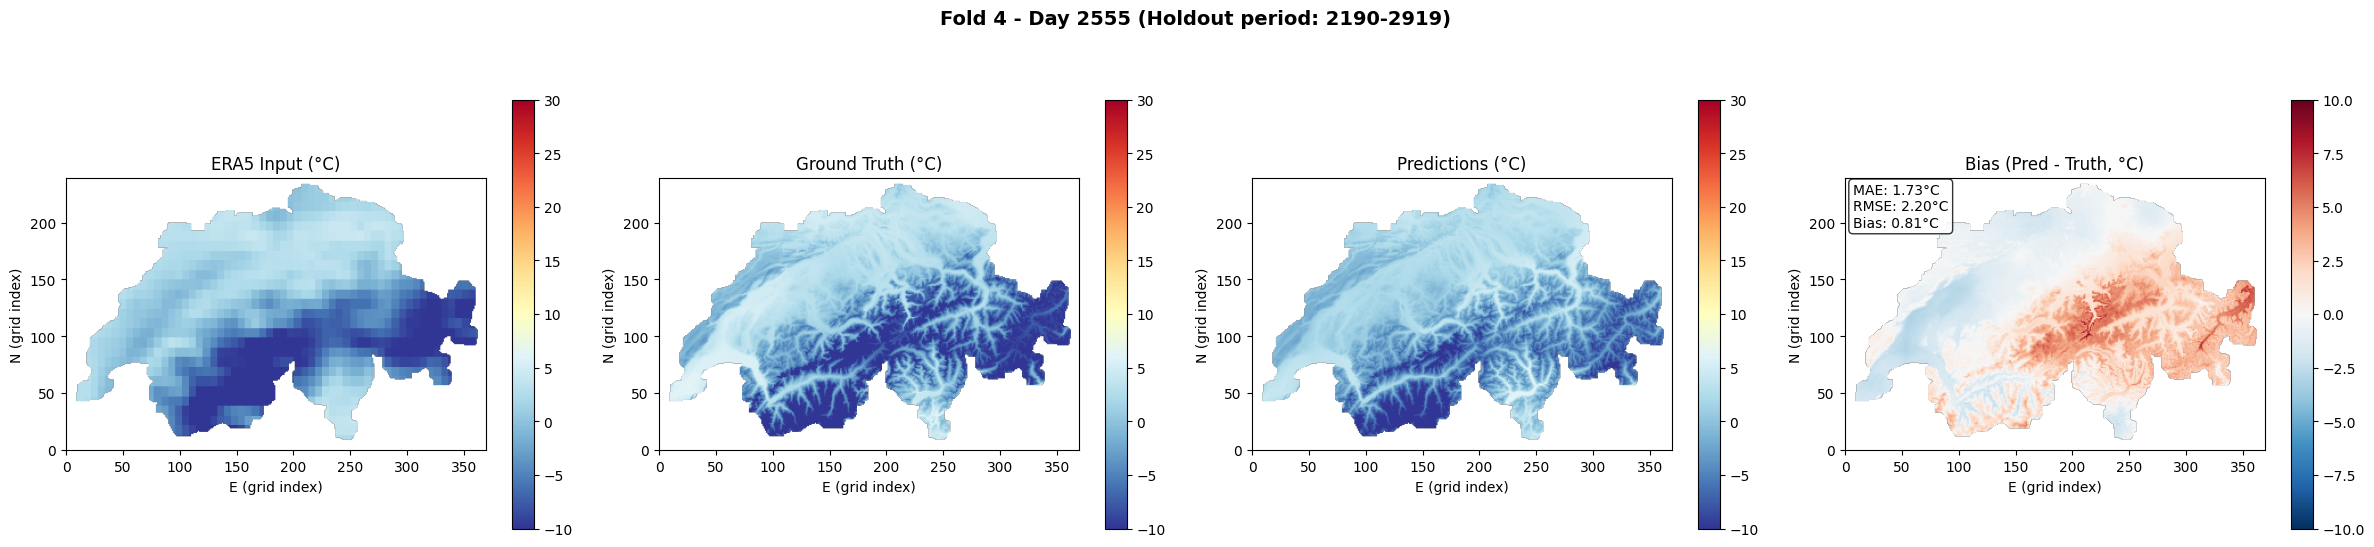

  Computing predictions for all 730 holdout days...
  Fold 4 done: accumulated 730 days

Fold 5/5
  Loaded model from epoch 28
  Holdout period: days 2920 to 3651 (732 days)
  Holdout date range: 2021-12-30T00:00:00.000000000 to 2023-12-31T00:00:00.000000000
  Selected day index for single-day plot: 3286


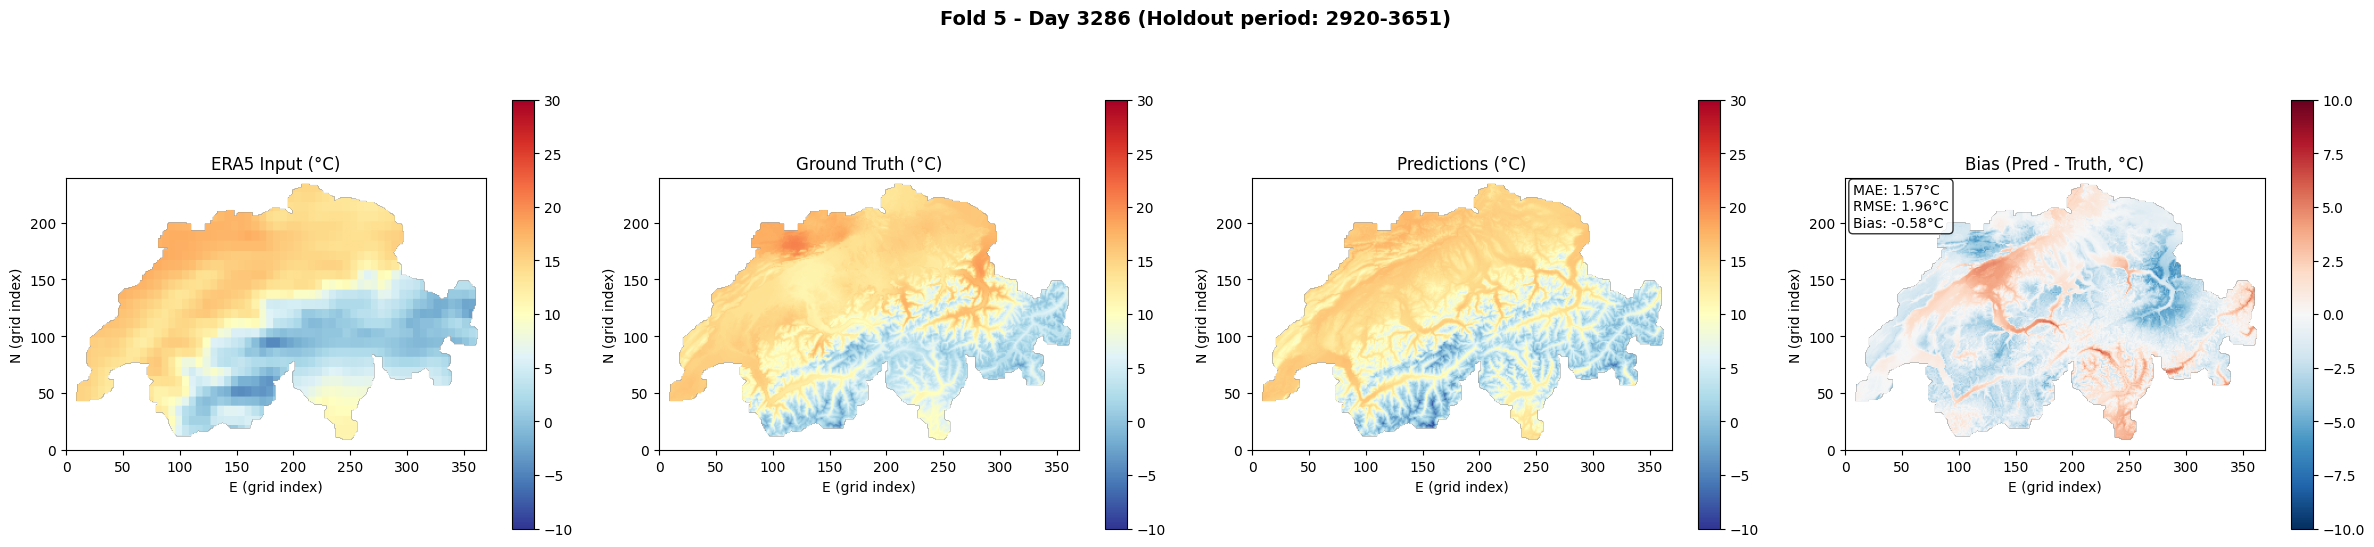

  Computing predictions for all 732 holdout days...
  Fold 5 done: accumulated 732 days

Combined holdout data: 3652 days x 88800 points


In [16]:
n_samples = era5_data.shape[0]
grid_shape = (grid_N, grid_E)
era5_shape = (era5_data.shape[2], era5_data.shape[3])  # (lat, lon)
N, E = grid_shape

print(f"Total time samples: {n_samples}")
print(f"Number of folds: {params.N_FOLDS}")
print(f"ERA5 grid shape: {era5_shape}")
print(f"MeteoSwiss grid shape: {grid_shape}")
print()

# Extract elevation and mTPI grids (these are static, same for all folds)
# elev tensor has shape (n_points, 3): [true_elev, elev_diff, mtpi]
elev_np = elev.cpu().numpy()
true_elev_grid = elev_np[:, 0].reshape(N, E)  # True elevation in meters
mtpi_grid = elev_np[:, 2].reshape(N, E)  # mTPI in meters

# Accumulators for combined holdout analysis
combined_errors = []       # List of (holdout_days_i, n_points) arrays
combined_preds = []        # Denormalized predictions (°C)
combined_sigmas = []       # Predicted sigma
combined_truths = []       # Denormalized ground truth (°C)
combined_dates = []        # Holdout dates for temporal analysis
combined_ref_preds = []    # ERA5 reference predictions for skill score

for fold in range(params.N_FOLDS):
    print(f"={'=' * 59}")
    print(f"Fold {fold + 1}/{params.N_FOLDS}")
    print(f"={'=' * 59}")
    
    # Load model checkpoint
    checkpoint_path = MODEL_DIR / f'model_fold_{fold}'
    if not checkpoint_path.exists():
        print(f"  Checkpoint not found: {checkpoint_path}")
        continue
    
    model, epoch = load_model_checkpoint(checkpoint_path, params, device)
    print(f"  Loaded model from epoch {epoch}")
    
    # Get holdout period for this fold
    holdout_start, holdout_end = get_fold_holdout_indices(fold, params.N_FOLDS, n_samples)
    holdout_days = holdout_end - holdout_start
    holdout_dates = era5_times[holdout_start:holdout_end]
    print(f"  Holdout period: days {holdout_start} to {holdout_end-1} ({holdout_days} days)")
    print(f"  Holdout date range: {holdout_dates[0]} to {holdout_dates[-1]}")
    
    # Select one day from holdout for the single-day visualization
    day_idx = select_holdout_day(fold, holdout_start, holdout_end, seed=params.SEED)
    print(f"  Selected day index for single-day plot: {day_idx}")
    
    # Generate predictions for single day visualization
    predictions, sigma = predict_single_day(model, era5_data, day_idx, dists, elev, seasonal_features, device)
    predictions_np = predictions.cpu().numpy()
    
    # Get ground truth and ERA5 input for single-day plot
    truth = target_y_tensor[day_idx].cpu().numpy()
    era5_temp = era5_data[day_idx, 0].cpu().numpy()
    
    # Plot single-day comparison (kept per fold)
    title = f"Fold {fold + 1} - Day {day_idx} (Holdout period: {holdout_start}-{holdout_end-1})"
    fig = plot_prediction_comparison(
        truth=truth,
        predictions=predictions_np,
        era5_input=era5_temp,
        grid_shape=grid_shape,
        era5_shape=era5_shape,
        metadata=metadata,
        title=title,
        denormalize=True
    )
    plt.show()
    
    # # Plot uncertainty vs error for the single day
    # N, E = grid_shape
    
    # # Denormalize predictions and truth for error calculation
    # pred_denorm = metadata.denormalize(predictions_np) - 273.15
    # truth_denorm = metadata.denormalize(truth) - 273.15
    
   
    # # Calculate absolute error
    # abs_error = np.abs(pred_denorm - truth_denorm)
    
    # # Reshape to grid
    # sigma_grid = sigma_np.reshape(N, E)
    # abs_error_grid = abs_error.reshape(N, E)
    
    # # Apply valid mask
    # sample_truth = truth.reshape(N, E)
    # valid_mask = ~np.isnan(sample_truth)
    # sigma_grid = np.where(valid_mask, sigma_grid, np.nan)
    # abs_error_grid = np.where(valid_mask, abs_error_grid, np.nan)
    
    # # Compute max observed values for plot ranges
    # max_sigma = np.nanmax(sigma_grid)
    # max_error = np.nanmax(abs_error_grid)
    
    # # Plot uncertainty vs error
    # uncertainty_title = f"Fold {fold + 1} - Day {day_idx}: Uncertainty vs Error"
    # fig_uncertainty = plot_uncertainty_vs_error(
    #     sigma_grid=sigma_grid,
    #     abs_error_grid=abs_error_grid,
    #     title=uncertainty_title,
    #     sigma_range=(0, max_sigma),
    #     error_range=(0, max_error)
    # )
    # plt.show()
    
    # Compute predictions for all holdout days and accumulate
    print(f"  Computing predictions for all {holdout_days} holdout days...")
    
    fold_errors = []
    fold_preds = []
    fold_sigmas = []
    fold_truths = []
    
    for holdout_day_idx in range(holdout_start, holdout_end):
        day_preds, day_sigmas = predict_single_day(model, era5_data, holdout_day_idx, dists, elev, seasonal_features, device)
        day_preds_np = day_preds.cpu().numpy()
        day_sigmas_np = day_sigmas.cpu().numpy()
        day_truth = target_y_tensor[holdout_day_idx].cpu().numpy()
        
        # Denormalize to Celsius
        day_preds_denorm = metadata.denormalize(day_preds_np) - 273.15
        day_truth_denorm = metadata.denormalize(day_truth) - 273.15
        
        fold_errors.append(day_preds_denorm - day_truth_denorm)
        fold_preds.append(day_preds_denorm)
        fold_sigmas.append(day_sigmas_np)
        fold_truths.append(day_truth_denorm)
    
    # Stack this fold's arrays: (holdout_days, n_points)
    fold_errors = np.stack(fold_errors, axis=0)
    fold_preds = np.stack(fold_preds, axis=0)
    fold_sigmas = np.stack(fold_sigmas, axis=0)
    fold_truths = np.stack(fold_truths, axis=0)
    
    # Accumulate across folds
    combined_errors.append(fold_errors)
    combined_preds.append(fold_preds)
    combined_sigmas.append(fold_sigmas)
    combined_truths.append(fold_truths)
    combined_dates.append(holdout_dates)
    combined_ref_preds.append(era5_ref_denorm[holdout_start:holdout_end])
    
    print(f"  Fold {fold + 1} done: accumulated {fold_errors.shape[0]} days")
    print()

# Concatenate all folds along time axis
all_errors = np.concatenate(combined_errors, axis=0)
all_preds_denorm = np.concatenate(combined_preds, axis=0)
all_sigmas = np.concatenate(combined_sigmas, axis=0)
all_truths_denorm = np.concatenate(combined_truths, axis=0)
all_holdout_dates = np.concatenate(combined_dates, axis=0)
all_ref_preds = np.concatenate(combined_ref_preds, axis=0)

print(f"Combined holdout data: {all_errors.shape[0]} days x {all_errors.shape[1]} points")

## Combined Holdout Analysis (All Folds)

The following plots use the concatenated holdout predictions from all folds, covering the entire year.

Computing combined metrics over 3652 holdout days from 5 folds
Overall CRPS: 1.257°C
Global skill score: 0.505
Overall MAE: 1.368°C
Overall RMSE: 1.788°C
Overall Bias: -0.004°C


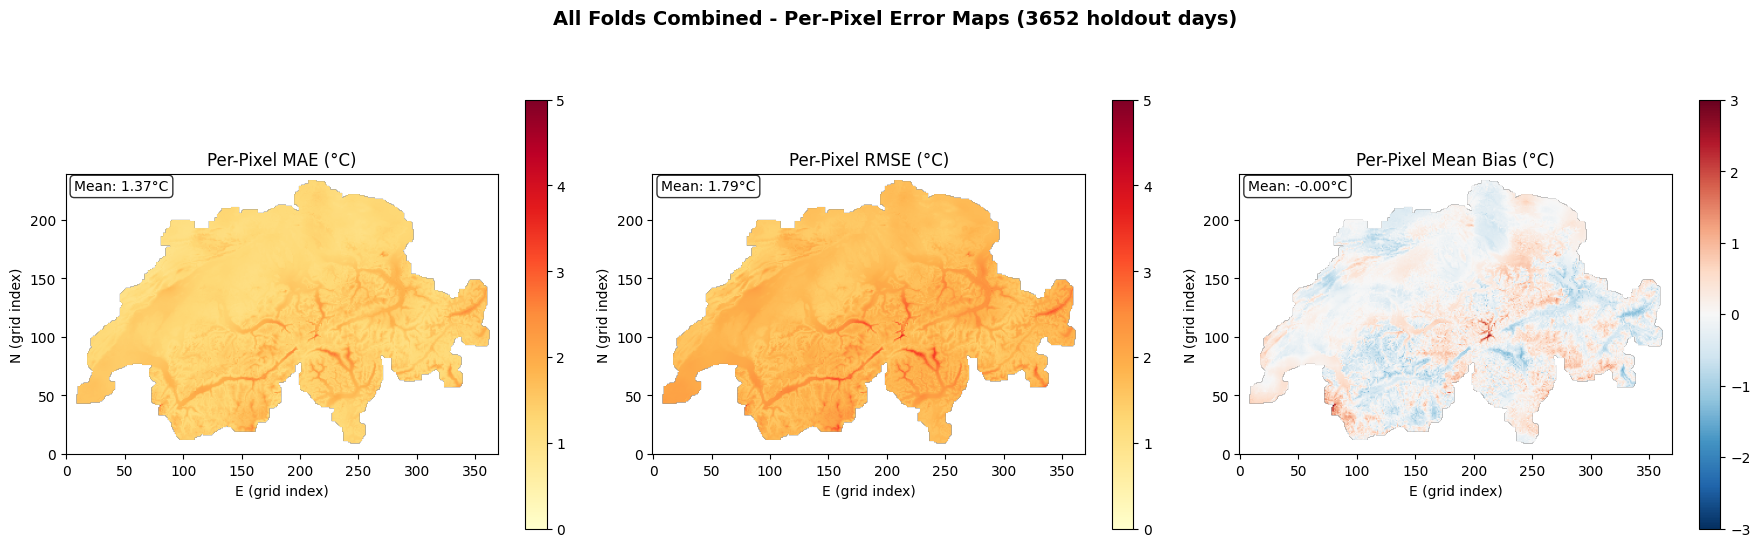

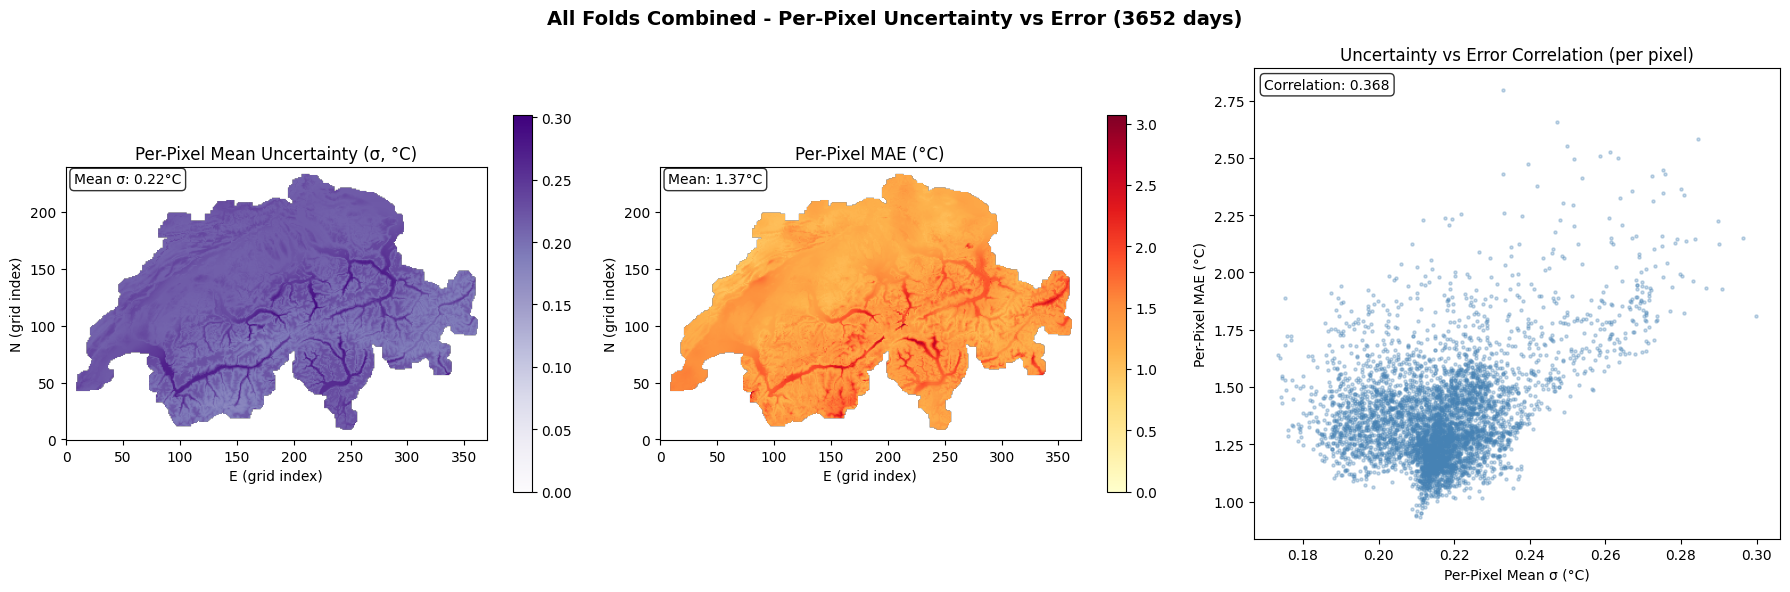

Per-pixel uncertainty-error correlation: 0.368


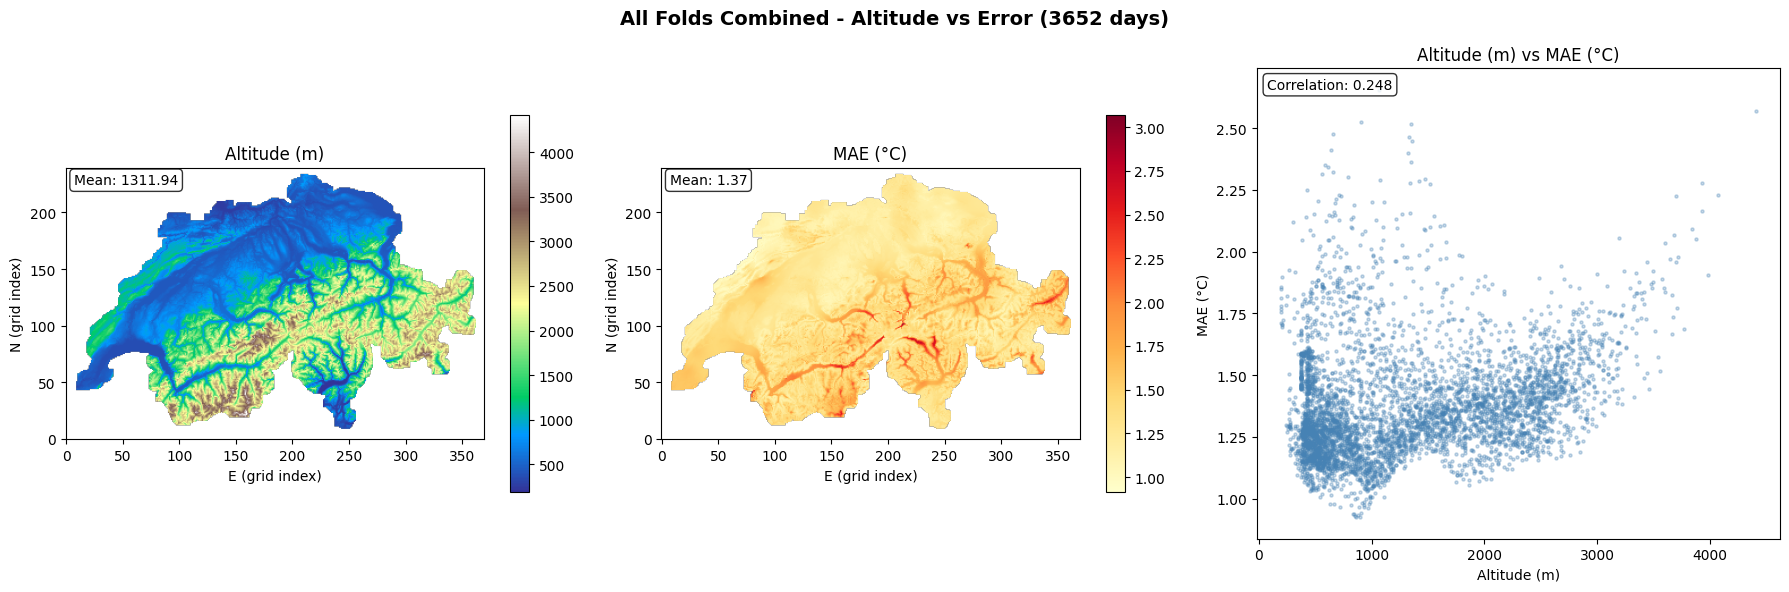

Altitude-error correlation: 0.248


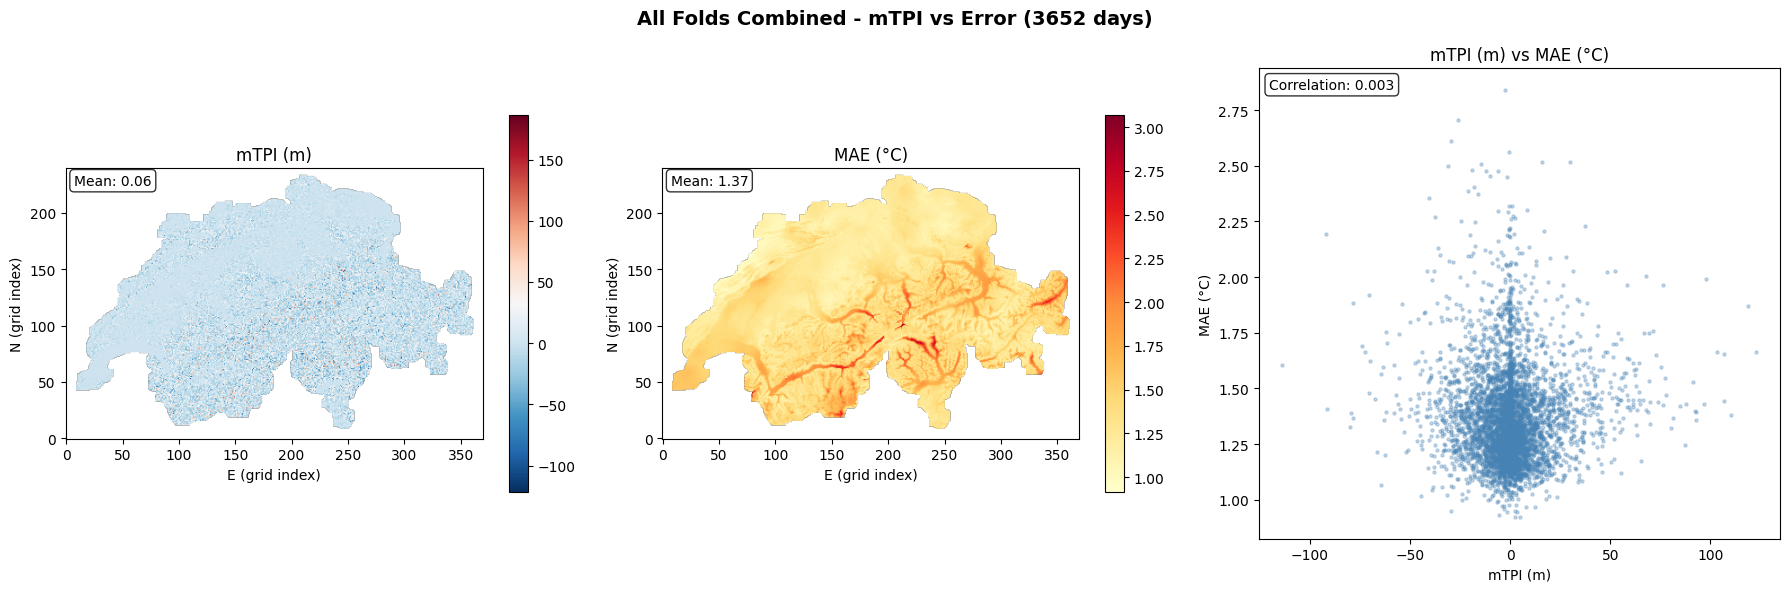

mTPI-error correlation: 0.003


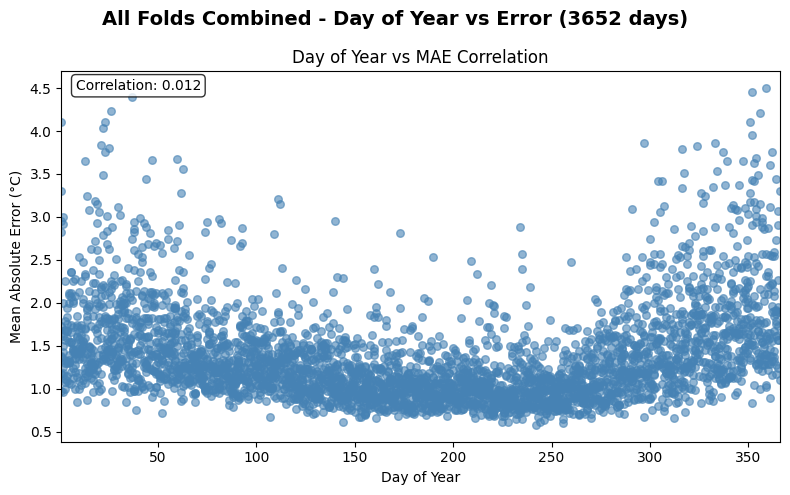

Day of year-error correlation: 0.012


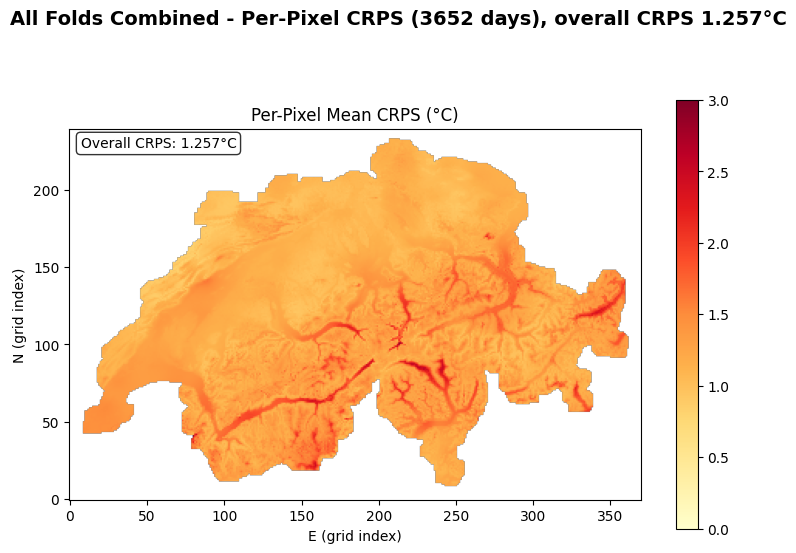

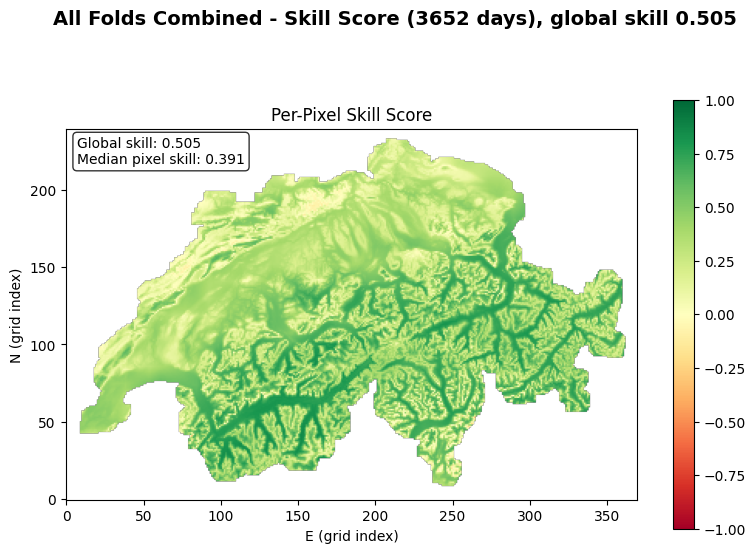

In [22]:
# --- Per-pixel metrics across all folds ---
total_days = all_errors.shape[0]
print(f"Computing combined metrics over {total_days} holdout days from {params.N_FOLDS} folds")

# Suppress "Mean of empty slice" warnings from pixels outside the valid MeteoSwiss mask
with warnings.catch_warnings():
    warnings.filterwarnings("ignore", message="Mean of empty slice", category=RuntimeWarning)

    # Per-pixel MAE, RMSE, bias, mean sigma
    mae_per_pixel = np.nanmean(np.abs(all_errors), axis=0)
    rmse_per_pixel = np.sqrt(np.nanmean(all_errors ** 2, axis=0))
    bias_per_pixel = np.nanmean(all_errors, axis=0)
    mean_sigma_per_pixel = np.nanmean(all_sigmas, axis=0)

    # CRPS (Gaussian predictions vs observations)
    crps_all = ps.crps_gaussian(all_truths_denorm, mu=all_preds_denorm, sig=all_sigmas)
    crps_per_pixel = np.nanmean(crps_all, axis=0)
    overall_crps = np.nanmean(crps_all)

    # Reference CRPS (deterministic ERA5 interpolation: CRPS = |pred - obs|)
    crps_ref_all = np.abs(all_ref_preds - all_truths_denorm)
    crps_ref_per_pixel = np.nanmean(crps_ref_all, axis=0)

print(f"Overall CRPS: {overall_crps:.3f}°C")

# Global skill score
global_skill = skill_score(np.nanmean(crps_all), np.nanmean(crps_ref_all))
print(f"Global skill score: {global_skill:.3f}")

# Overall MAE and RMSE
print(f"Overall MAE: {np.nanmean(mae_per_pixel):.3f}°C")
print(f"Overall RMSE: {np.nanmean(rmse_per_pixel):.3f}°C")
print(f"Overall Bias: {np.nanmean(bias_per_pixel):.3f}°C")

# Reshape to grids and apply valid mask
sample_truth = target_y_tensor[0].cpu().numpy().reshape(N, E)
valid_mask = ~np.isnan(sample_truth)

mae_grid = np.where(valid_mask, mae_per_pixel.reshape(N, E), np.nan)
rmse_grid = np.where(valid_mask, rmse_per_pixel.reshape(N, E), np.nan)
bias_grid = np.where(valid_mask, bias_per_pixel.reshape(N, E), np.nan)
crps_grid = np.where(valid_mask, crps_per_pixel.reshape(N, E), np.nan)
mean_sigma_grid = np.where(valid_mask, mean_sigma_per_pixel.reshape(N, E), np.nan)
true_elev_grid_masked = np.where(valid_mask, true_elev_grid, np.nan)
mtpi_grid_masked = np.where(valid_mask, mtpi_grid, np.nan)

# Per-pixel skill score
skill_per_pixel = 1.0 - (crps_per_pixel / crps_ref_per_pixel)
skill_grid = np.where(valid_mask, skill_per_pixel.reshape(N, E), np.nan)

# --- Plots ---

# 1. Error maps
fig_errors = plot_error_maps(
    mae_grid=mae_grid, rmse_grid=rmse_grid, bias_grid=bias_grid,
    title=f"All Folds Combined - Per-Pixel Error Maps ({total_days} holdout days)",
    error_range=(0, 5), bias_range=(-3, 3)
)
plt.show()

# 2. Per-pixel uncertainty vs error
fig_unc, perpixel_corr = plot_perpixel_uncertainty_vs_error(
    mean_sigma_grid=mean_sigma_grid, mae_grid=mae_grid,
    title=f"All Folds Combined - Per-Pixel Uncertainty vs Error ({total_days} days)",
    sigma_range=(0, np.nanmax(mean_sigma_grid)),
    error_range=(0, np.nanmax(mae_grid))
)
plt.show()
print(f"Per-pixel uncertainty-error correlation: {perpixel_corr:.3f}")

# 3. Altitude vs error
fig_alt, alt_corr = plot_perpixel_correlation(
    x_grid=true_elev_grid_masked, y_grid=mae_grid,
    x_label='Altitude (m)', y_label='MAE (°C)',
    title=f"All Folds Combined - Altitude vs Error ({total_days} days)",
    x_cmap='terrain', y_cmap='YlOrRd'
)
plt.show()
print(f"Altitude-error correlation: {alt_corr:.3f}")

# 4. mTPI vs error
fig_mtpi, mtpi_corr = plot_perpixel_correlation(
    x_grid=mtpi_grid_masked, y_grid=mae_grid,
    x_label='mTPI (m)', y_label='MAE (°C)',
    title=f"All Folds Combined - mTPI vs Error ({total_days} days)",
    x_cmap='RdBu_r', y_cmap='YlOrRd'
)
plt.show()
print(f"mTPI-error correlation: {mtpi_corr:.3f}")

# 5. Day of year vs error
fig_doy, doy_corr = plot_temporal_error_analysis(
    all_errors=all_errors, holdout_dates=all_holdout_dates,
    title=f"All Folds Combined - Day of Year vs Error ({total_days} days)"
)
plt.show()
print(f"Day of year-error correlation: {doy_corr:.3f}")

# 6. CRPS map
fig_crps, _ = plot_crps_map(
    crps_grid=crps_grid,
    title=f"All Folds Combined - Per-Pixel CRPS ({total_days} days), overall CRPS {overall_crps:.3f}°C",
    crps_range=(0, 3)
)
plt.show()

# 7. Skill score map
fig_skill = plot_skill_map(
    skill_grid=skill_grid, global_skill=global_skill,
    title=f"All Folds Combined - Skill Score ({total_days} days), global skill {global_skill:.3f}"
)
plt.show()

## Summary

This notebook demonstrates how to:
1. Load trained convCNP models using saved configuration (one per fold)
2. Reconstruct the holdout time periods used during cross-validation
3. Generate spatial predictions for the entire MeteoSwiss grid
4. **Per-fold:** Visualize a single representative day showing ERA5 input, ground truth, predictions, and bias
   The residual maps show where the model performs well (white) and where it struggles (blue=lower predictions, red=higher predictions).
5. **Combined across all folds:** Since holdout periods are non-overlapping, predictions from all folds are concatenated to produce a unified evaluation covering the entire year:
   - Per-pixel error maps (MAE, RMSE, bias)
   - Uncertainty calibration (predicted σ vs actual MAE)
   - Error correlations with altitude and mTPI
   - Temporal error patterns (day-of-year analysis)
   - CRPS (Continuous Ranked Probability Score) for probabilistic calibration
   - Skill score relative to ERA5 bilinear interpolation baseline

### Interpretation of correlation plots:
- **Uncertainty vs Error:** High correlation indicates good calibration - the model "knows where it doesn't know"
- **Altitude vs Error:** Positive correlation suggests the model struggles more at high elevations
- **mTPI vs Error:** Positive values = ridges, negative = valleys. Correlation reveals terrain-dependent biases
- **Day of Year vs Error:** Reveals seasonal performance variations across the holdout period